In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import math
import os
import json
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import Input, Concatenate

In [2]:
# 1. leer normal (una sola cabecera)
df = pd.read_csv("../csv/bbva_enriched.csv")
df.head()

,Unnamed: 0,Date,SAN_Price,BBVA_Adj_Close,BBVA_Close,BBVA_Volume,BBVA_High,BBVA_Low,BBVA_Open,IBEX,SP500,EURUSD,OIL,eventos_negativos,vix,vix.1,vix.2,vix.3,vix.4,vix.5
0,0,2003-12-01,7.746234,3.304151,9.895663,25801137,9.895663,9.645869,9.895663,7372.299805,1070.119995,1.196501,29.950001,0,16.770000,16.770000,17.030001,16.170000,16.740000,0
1,1,2003-12-02,7.711614,3.291320,9.857233,22303620,9.905270,9.770766,9.857233,7348.700195,1066.619995,1.208897,30.780001,0,16.270000,16.270000,16.889999,16.170000,16.889999,0
2,2,2003-12-03,7.763544,3.313776,9.924485,14010666,9.934092,9.780373,9.924485,7384.299805,1064.729980,1.212298,31.100000,0,16.629999,16.629999,16.680000,15.770000,16.080000,0
3,3,2003-12-04,7.728924,3.323397,9.953307,19892058,9.972522,9.809196,9.953307,7367.100098,1069.719971,1.208094,31.260000,0,16.299999,16.299999,16.830000,16.290001,16.480000,0
4,4,2003-12-05,7.702959,3.291320,9.857233,12585450,9.962915,9.818803,9.857233,7348.100098,1061.500000,1.218695,30.730000,0,17.090000,17.090000,17.320000,16.500000,16.760000,0


In [3]:
# 1. leer normal (una sola cabecera)
df = pd.read_csv("../csv/bbva_enriched.csv")
df.head()

,Unnamed: 0,Date,SAN_Price,BBVA_Adj_Close,BBVA_Close,BBVA_Volume,BBVA_High,BBVA_Low,BBVA_Open,IBEX,SP500,EURUSD,OIL,eventos_negativos,vix,vix.1,vix.2,vix.3,vix.4,vix.5
0,0,2003-12-01,7.746234,3.304151,9.895663,25801137,9.895663,9.645869,9.895663,7372.299805,1070.119995,1.196501,29.950001,0,16.770000,16.770000,17.030001,16.170000,16.740000,0
1,1,2003-12-02,7.711614,3.291320,9.857233,22303620,9.905270,9.770766,9.857233,7348.700195,1066.619995,1.208897,30.780001,0,16.270000,16.270000,16.889999,16.170000,16.889999,0
2,2,2003-12-03,7.763544,3.313776,9.924485,14010666,9.934092,9.780373,9.924485,7384.299805,1064.729980,1.212298,31.100000,0,16.629999,16.629999,16.680000,15.770000,16.080000,0
3,3,2003-12-04,7.728924,3.323397,9.953307,19892058,9.972522,9.809196,9.953307,7367.100098,1069.719971,1.208094,31.260000,0,16.299999,16.299999,16.830000,16.290001,16.480000,0
4,4,2003-12-05,7.702959,3.291320,9.857233,12585450,9.962915,9.818803,9.857233,7348.100098,1061.500000,1.218695,30.730000,0,17.090000,17.090000,17.320000,16.500000,16.760000,0


In [4]:
# 1) cargar
df = pd.read_csv("../csv/bbva_enriched.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# 2) quitar columnas que sobran
cols_to_drop = ["Unnamed: 0", "vix.1", "vix.2", "vix.3", "vix.4", "vix.5"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 3) definir grupos de columnas
fin_cols = [
    "BBVA_Adj_Close", "BBVA_Close", "BBVA_Volume", "BBVA_High",
    "BBVA_Low", "BBVA_Open", "SAN_Price", "IBEX", "SP500", "EURUSD", "OIL"
]
macro_like = [
    "gdp_growth_x", "gdp_growth_y",
    "hicp_es", "hicp_es_yoy", "hicp_es_gap_ecb",
    "ecb_refi_rate", "ecb_refi_rate_diff",
    "bce_hike", "bce_hike_strict",
    "house_price_index_es"
]
bin_like = ["eventos_negativos"]

fin_cols = [c for c in fin_cols if c in df.columns]
macro_like = [c for c in macro_like if c in df.columns]
bin_like = [c for c in bin_like if c in df.columns]

# 4) rellenar financieras
df[fin_cols] = df[fin_cols].interpolate(method="linear", limit_direction="both")

# 5) rellenar macro
df[macro_like] = df[macro_like].ffill().bfill()

# 6) binarias
for c in bin_like:
    df[c] = df[c].fillna(0)

# 7) lo que quede
for c in df.columns:
    if df[c].isna().any():
        df[c] = df[c].fillna(0)

print("NaN totales después de rellenar:", df.isna().sum().sum())

# dejamos la fecha como índice
df = df.set_index("Date")


NaN totales después de rellenar: 0


In [5]:
# asumimos que ya tienes estas columnas:
# BBVA_Open, BBVA_High, BBVA_Low, BBVA_Close

df["day_range"] = df["BBVA_High"] - df["BBVA_Low"]
df["close_vs_open"] = df["BBVA_Close"] - df["BBVA_Open"]

# evitar división por cero
eps = 1e-6
df["close_pos_in_range"] = (df["BBVA_Close"] - df["BBVA_Low"]) / (
    (df["BBVA_High"] - df["BBVA_Low"]) + eps
)

# sombras (opcionales)
df["upper_shadow"] = df["BBVA_High"] - df[["BBVA_Open", "BBVA_Close"]].max(axis=1)
df["lower_shadow"] = df[["BBVA_Open", "BBVA_Close"]].min(axis=1) - df["BBVA_Low"]

In [6]:
def preparar_datos_multivariados(df, target_col="BBVA_Close", window_size=25):
    df = df.sort_index()

    selected_features = [
    "BBVA_Adj_Close",
    "BBVA_Volume",
    "BBVA_High",
    "BBVA_Low",
    "BBVA_Open",
    "SAN_Price",
    "IBEX",
    "SP500",
    "EURUSD",
    "OIL",
    "vix",
    "eventos_negativos",
]

    feature_cols = [c for c in selected_features if c in df.columns]
    features = df[feature_cols].copy()
    target = df[[target_col]].copy()

    X, y = [], []
    for i in range(window_size, len(features)):
        X.append(features.iloc[i-window_size:i].values)
        y.append(target.iloc[i].values[0])

    return np.array(X), np.array(y), feature_cols

In [7]:
X, y, feature_cols = preparar_datos_multivariados(
    df,
    target_col="BBVA_Close",
    window_size=25
)
print(X.shape, y.shape)
print(feature_cols)

(5387, 25, 12) (5387,)
['BBVA_Adj_Close', 'BBVA_Volume', 'BBVA_High', 'BBVA_Low', 'BBVA_Open', 'SAN_Price', 'IBEX', 'SP500', 'EURUSD', 'OIL', 'vix', 'eventos_negativos']


In [8]:
# =============== ESCALADO CORRECTO ===============
n_timesteps = X.shape[1]
n_features = X.shape[2]

# Re-formatear para escalar por feature
X_2d = X.reshape(-1, n_features)

# Escalado de entrada
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_2d).reshape(-1, n_timesteps, n_features)

# Escalado del target
y = y.reshape(-1, 1)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

# Asignar conjuntos (solo entrenamiento)
X_train = X_scaled
y_train = y_scaled

print("Train:", X_train.shape, y_train.shape)


Train: (5387, 25, 12) (5387, 1)


In [9]:
def build_lstm_skip(window_size, n_features):
    seq_input = Input(shape=(window_size, n_features))
    x = LSTM(48, return_sequences=True, dropout=0.05, recurrent_dropout=0.05)(seq_input)
    x = LSTM(32, dropout=0.05, recurrent_dropout=0.05)(x)
    x = Dense(32, activation="relu")(x)
    last_step = seq_input[:, -1, :]
    x = Concatenate()([x, last_step])
    out = Dense(1)(x)
    model = Model(seq_input, out)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")
    return model

In [10]:
import os, json

# ==============================
# CONFIGURACIÓN BASE
# ==============================
EPOCHS_DEFAULT = 800
EPOCHS_LSTM_SKIP = 2000
BATCH = 32
window_size = 25

# Crear carpeta 'modelos' fuera de notebooks si no existe
modelos_dir = os.path.join("..", "modelos")
os.makedirs(modelos_dir, exist_ok=True)

# ==============================
# FUNCIÓN DE ENTRENAMIENTO (solo train)
# ==============================
def entrenar_modelo(nombre, build_fn, X_train, y_train, window_size):
    print(f"\n🧠 Entrenando modelo {nombre}...\n")
    n_features = X_train.shape[2]
    model = build_fn(window_size, n_features)

    model_path = os.path.join(modelos_dir, f"mejor_{nombre.lower()}_bbva.h5")

    early_stop = EarlyStopping(
        monitor="loss",
        patience=150 if nombre == "LSTM_Skip" else 100,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor="loss",
        save_best_only=True,
        verbose=1
    )

    epochs = EPOCHS_LSTM_SKIP if nombre == "LSTM_Skip" else EPOCHS_DEFAULT

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=BATCH,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    # guardar history (opcional)
    hist_path = os.path.join(modelos_dir, f"hist_{nombre.lower()}_BBVA.json")
    with open(hist_path, "w") as f:
        json.dump(history.history, f)

    print(f"✅ Modelo {nombre} finalizado ({len(history.history['loss'])} epochs entrenadas)")
    return model, history

# ==============================
# ENTRENAR MODELO LSTM_SKIP
# ==============================
lstm_skip_model, hist_lstm_skip = entrenar_modelo(
    "LSTM_Skip",
    build_lstm_skip,
    X_train,   # usa directamente todo el dataset ya escalado
    y_train,
    window_size
)




🧠 Entrenando modelo LSTM_Skip...

Epoch 1/2000
167/169 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0456
Epoch 1: loss improved from None to 0.01569, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0157
Epoch 2/2000
167/169 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0044
Epoch 2: loss improved from 0.01569 to 0.00387, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0039
Epoch 3/2000
165/169 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0025
Epoch 3: loss improved from 0.00387 to 0.00229, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0023
Epoch 4/2000
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0018
Epoch 4: loss improved from 0.00229 to 0.00164, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0016
Epoch 5/2000
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0014
Epoch 5: loss improved from 0.00164 to 0.00131, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


...

169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.6872e-05
Epoch 1720/2000
166/169 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.9977e-05
Epoch 1720: loss did not improve from 0.00005
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.8665e-05
Epoch 1721/2000
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.2576e-05
Epoch 1721: loss did not improve from 0.00005
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.0677e-05
Epoch 1722/2000
166/169 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.7146e-05
Epoch 1722: loss did not improve from 0.00005
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.9528e-05
Epoch 1723/2000
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.0004e-05
Epoch 1723: loss did not improve from 0.00005
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.0207e-05
Epoch 1724/2000
167/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.1341e-05
Epoch 1724: loss did not improve from 0.00005
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.1337e-05
Epoch 1725/2000
168

169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.6694e-05
Epoch 1743/2000
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.8957e-05
Epoch 1743: loss did not improve from 0.00005
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 4.9375e-05
Epoch 1744/2000
168/169 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.6654e-05
Epoch 1744: loss did not improve from 0.00005
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.7128e-05
Epoch 1745/2000
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.6381e-05
Epoch 1745: loss did not improve from 0.00005
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.7223e-05
Epoch 1746/2000
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.5984e-05
Epoch 1746: loss did not improve from 0.00005
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.6971e-05
Epoch 1747/2000
166/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.3929e-05
Epoch 1747: loss improved from 0.00005 to 0.00004, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.4727e-05
Epoch 1748/2000
165/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.8012e-05
Epoch 1748: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.0382e-05
Epoch 1749/2000
165/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.7491e-05
Epoch 1749: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.7641e-05
Epoch 1750/2000
167/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.4627e-05
Epoch 1750: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.7492e-05
Epoch 1751/2000
166/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.7550e-05
Epoch 1751: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.7736e-05
Epoch 1752/2000
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.7800e-05
Epoch 1752: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.9306e-05
Epoch 1753/2000
167

169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.4684e-05
Epoch 1846/2000
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.7390e-05
Epoch 1846: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.7389e-05
Epoch 1847/2000
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.8034e-05
Epoch 1847: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.9934e-05
Epoch 1848/2000
165/169 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.9433e-05
Epoch 1848: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.9660e-05
Epoch 1849/2000
167/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.3577e-05
Epoch 1849: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.5654e-05
Epoch 1850/2000
166/169 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.7731e-05
Epoch 1850: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.7542e-05
Epoch 1851/2000
168

169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.2899e-05
Epoch 1907/2000
167/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.7454e-05
Epoch 1907: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.6318e-05
Epoch 1908/2000
165/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.4968e-05
Epoch 1908: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.7037e-05
Epoch 1909/2000
167/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.4808e-05
Epoch 1909: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.5837e-05
Epoch 1910/2000
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.8479e-05
Epoch 1910: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.7470e-05
Epoch 1911/2000
166/169 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.5949e-05
Epoch 1911: loss did not improve from 0.00004
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.5621e-05
Epoch 1912/2000
168

In [11]:
# predicciones sobre TODO el conjunto (el que entrenaste)
y_pred_lstm_skip_scaled = lstm_skip_model.predict(X_train)

# desescalar la y real
y_train_real = scaler_y.inverse_transform(y_train.reshape(-1, 1))

# desescalar las predicciones
pred_lstm_skip_real = scaler_y.inverse_transform(y_pred_lstm_skip_scaled)


169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [12]:
def evaluar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# evaluar sobre todo el conjunto usado para entrenar
mae_lstm_skip, rmse_lstm_skip = evaluar(y_train_real, pred_lstm_skip_real)

print("LSTM_Skip -> MAE:", mae_lstm_skip, "RMSE:", rmse_lstm_skip)

LSTM_Skip -> MAE: 0.0764103593466919 RMSE: 0.09811621671403481


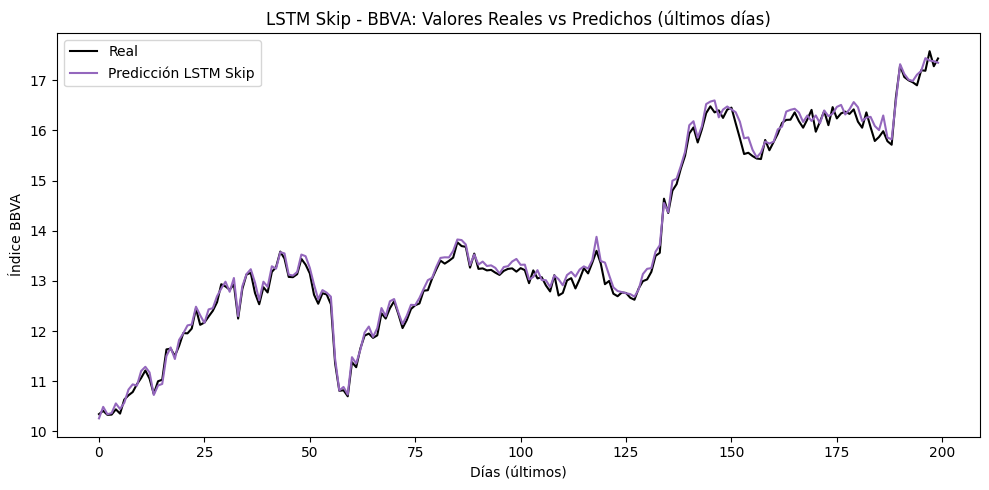

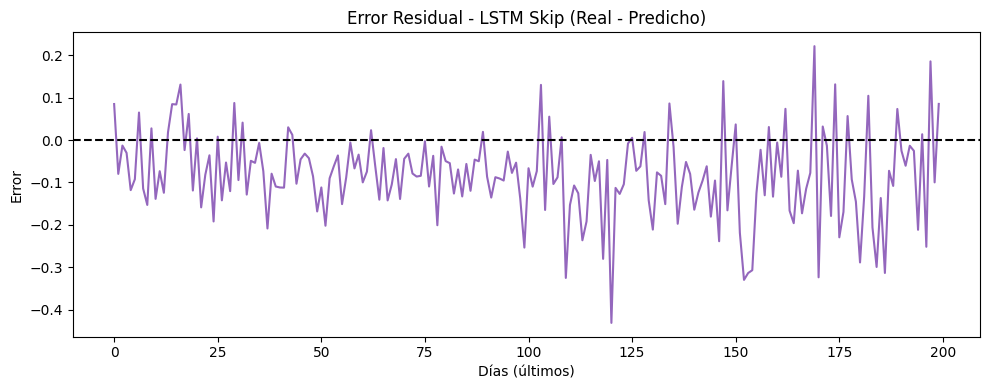

In [13]:
# --- Tramo a mostrar (últimos 200 días del entrenamiento) ---
n_mostrar = 200
y_real_plot = y_train_real[-n_mostrar:]
pred_lstm_skip_plot = pred_lstm_skip_real[-n_mostrar:]

# ===============================
#  LSTM Skip
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_lstm_skip_plot, label="Predicción LSTM Skip", color="tab:purple")
plt.title("LSTM Skip - BBVA: Valores Reales vs Predichos (últimos días)")
plt.xlabel("Días (últimos)")
plt.ylabel("Índice BBVA")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error LSTM Skip ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_lstm_skip_plot, color="tab:purple")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - LSTM Skip (Real - Predicho)")
plt.xlabel("Días (últimos)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()


In [14]:
def predecir_siguiente_multivariante(
    model,
    df_original,
    feature_cols,
    scaler_X,
    scaler_y,
    target_col="BBVA_Close",
    window_size=25
):
    """
    Predice el siguiente valor del target_col usando LAS MISMAS feature_cols que en el entrenamiento.
    """
    # 1) nos quedamos solo con las columnas que usó el modelo
    features = df_original[feature_cols].copy()

    # 2) últimos window_size pasos
    ultimos = features.values[-window_size:]

    # 3) escalar con el scaler_X que ya estaba fit
    ultimos_scaled = scaler_X.transform(ultimos)

    # 4) forma (1, window_size, n_features)
    X_input = ultimos_scaled.reshape((1, window_size, len(feature_cols)))

    # 5) predecir (escala 0-1)
    pred_scaled = model.predict(X_input)

    # 6) desescalar al valor real
    pred_real = scaler_y.inverse_transform(pred_scaled)

    # devolvemos escalar
    return pred_real[0, 0]


def predecir_n_dias(
    model,
    df_original,
    feature_cols,
    scaler_X,
    scaler_y,
    n_dias=5,
    target_col="BBVA_Close",
    window_size=25
):
    """
    Predicción recursiva n_dias hacia delante.
    Va añadiendo las predicciones al df temporal para que el siguiente paso tenga contexto.
    """
    df_temp = df_original.copy()
    predicciones = []

    for _ in range(n_dias):
        siguiente = predecir_siguiente_multivariante(
            model=model,
            df_original=df_temp,
            feature_cols=feature_cols,
            scaler_X=scaler_X,
            scaler_y=scaler_y,
            target_col=target_col,
            window_size=window_size
        )
        predicciones.append(siguiente)

        # construimos una nueva fila copiando la última
        nueva_fila = df_temp.iloc[-1].copy()

        # actualizamos SOLO el target
        nueva_fila[target_col] = siguiente

        # añadimos la fila al df temporal
        df_temp = pd.concat([df_temp, nueva_fila.to_frame().T], ignore_index=True)

    return predicciones


# ====== USO ======
preds_5 = predecir_n_dias(
    model=lstm_skip_model,
    df_original=df.reset_index(drop=False),   # por si Date era índice
    feature_cols=feature_cols,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    n_dias=5,
    target_col="BBVA_Close",
    window_size=25
)

print("Predicciones próximos 5 días:")
for i, p in enumerate(preds_5, 1):
    print(f"Día +{i}: {p:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Predicciones próximos 5 días:
Día +1: 17.7612
Día +2: 17.6221
Día +3: 17.4187
Día +4: 17.4372
Día +5: 17.5588


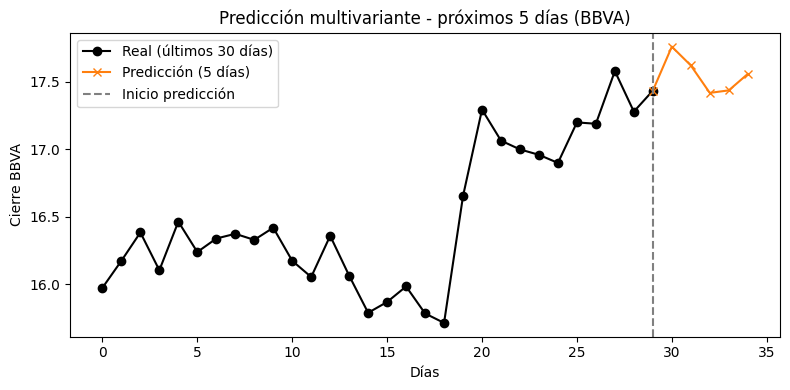

In [15]:
# últimos 30 días reales
ultimos_reales = df["BBVA_Close"].tail(30).values

# concatenar los 30 reales + 5 predichos
serie_completa = np.concatenate([ultimos_reales, np.array(preds_5)])

# índices para graficar
x_reales = range(len(ultimos_reales))
x_pred = range(len(ultimos_reales)-1, len(serie_completa))

plt.figure(figsize=(8,4))
plt.plot(x_reales, ultimos_reales, label="Real (últimos 30 días)", color="black", marker="o")
plt.plot(x_pred, serie_completa[len(ultimos_reales)-1:], label="Predicción (5 días)", color="tab:orange", marker="x")

plt.axvline(len(ultimos_reales)-1, color="gray", linestyle="--", label="Inicio predicción")
plt.title("Predicción multivariante - próximos 5 días (BBVA)")
plt.xlabel("Días")
plt.ylabel("Cierre BBVA")
plt.legend()
plt.tight_layout()
plt.show()
